Upload your BTP data file (Excel .xlsx or CSV .csv):


Saving BTP.xlsx to BTP.xlsx

Processing file: BTP.xlsx
Data loaded successfully.

Processing windows...


Creating Windows: 100%|██████████| 1123/1123 [00:00<00:00, 120314.78it/s]

Dataset shape: X=(1123, 600), y=(1123, 300)

Training XGBoost model...
Note: Using Native Multi-Target support (no wrapper). This is much faster.


Training on: CUDA
Training complete!


/usr/local/lib/python3.12/dist-packages/xgboost/core.py:774: UserWarning: [18:17:05] WARNING: /workspace/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)



Test Set Metrics:
Overall RMSE: 0.000894
Overall MAE:  0.000526


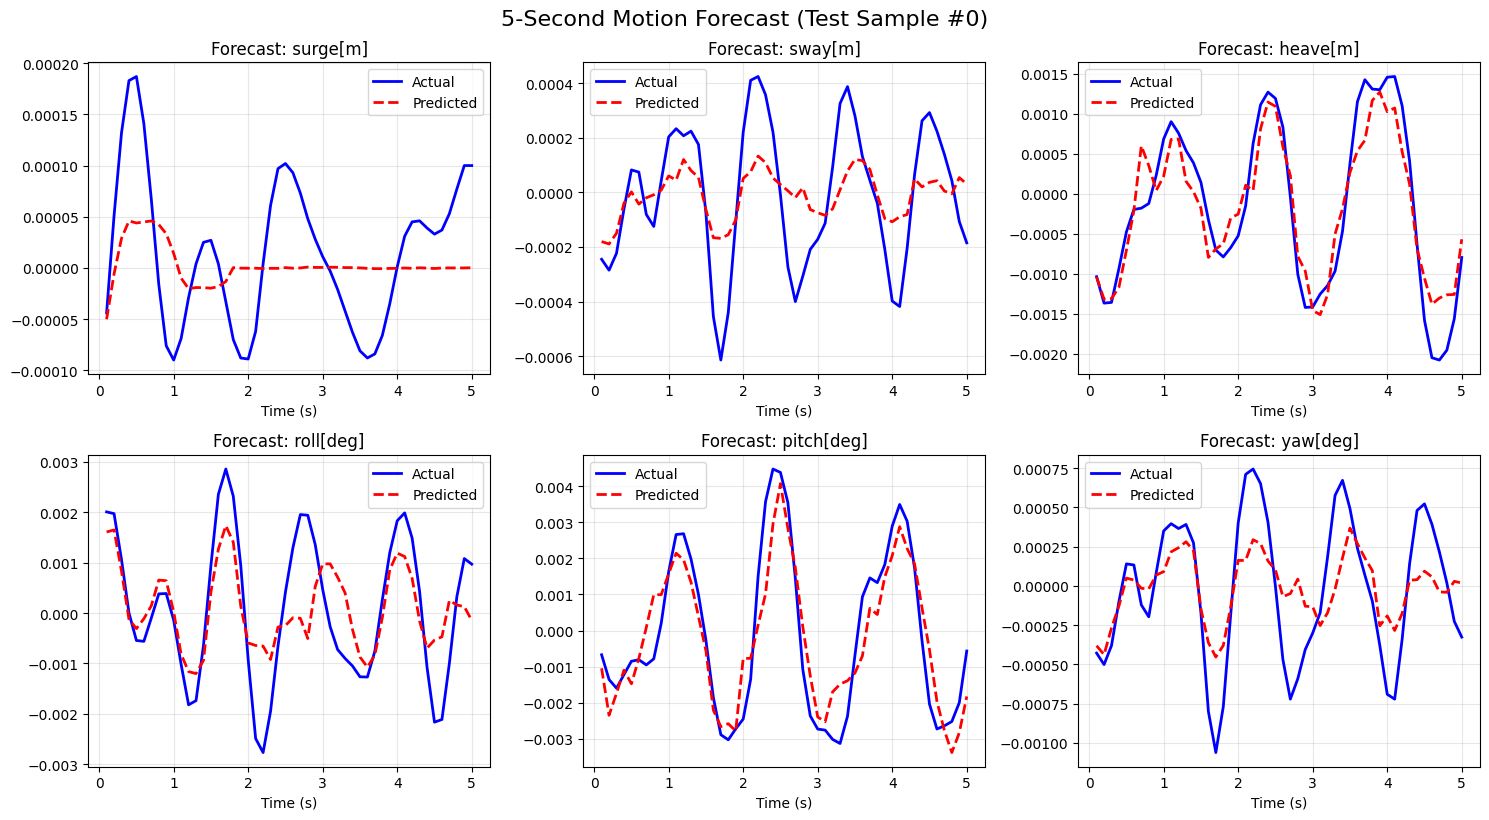

In [ ]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import io
from google.colab import files
from tqdm import tqdm  # Progress bar

# ==========================================
# 1. UPLOAD DATA FILE
# ==========================================
print("Upload your BTP data file (Excel .xlsx or CSV .csv):")
uploaded = files.upload()

filename = next(iter(uploaded))
print(f"\nProcessing file: {filename}")

try:
    if filename.endswith('.csv'):
        df = pd.read_csv(io.BytesIO(uploaded[filename]))
    else:
        # Try reading specific sheet, else default
        try:
            df = pd.read_excel(io.BytesIO(uploaded[filename]), sheet_name='Time-Series Data')
        except:
            df = pd.read_excel(io.BytesIO(uploaded[filename]))
    print("Data loaded successfully.")

except Exception as e:
    print(f"Error loading file: {e}")
    raise

# ==========================================
# 2. PREPROCESS DATA
# ==========================================
target_cols = ['surge[m]', 'sway[m]', 'heave[m]', 'roll[deg]', 'pitch[deg]', 'yaw[deg]']

# Clean column names just in case
df.columns = df.columns.str.strip()
data_6dof = df[target_cols].values

def create_windows(data, input_steps=100, output_steps=50):
    X, y = [], []
    total_len = len(data)
    # Loop with progress bar
    for i in tqdm(range(total_len - input_steps - output_steps + 1), desc="Creating Windows"):
        X.append(data[i : i + input_steps].flatten())
        y.append(data[i + input_steps : i + input_steps + output_steps].flatten())
    return np.array(X), np.array(y)

input_steps = 100
output_steps = 50

print("\nProcessing windows...")
X, y = create_windows(data_6dof, input_steps, output_steps)
print(f"Dataset shape: X={X.shape}, y={y.shape}")

split_idx = int(0.8 * len(X))
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

# ==========================================
# 3. TRAIN XGBOOST MODEL (FAST VERSION)
# ==========================================
print("\nTraining XGBoost model...")
print("Note: Using Native Multi-Target support (no wrapper). This is much faster.")

# Check for GPU
try:
    import torch
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    tree_method = 'hist' # 'hist' is generally faster for larger data
except:
    device = 'cpu'
    tree_method = 'hist'

print(f"Training on: {device.upper()}")

# NATIVE MULTI-OUTPUT CONFIGURATION
# We removed MultiOutputRegressor. XGBoost >= 1.6.0 handles 2D y-arrays automatically.
model = xgb.XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    tree_method=tree_method,
    device=device,
    n_jobs=-1,
    random_state=42
)

# Fit directly on the 2D array
model.fit(X_train, y_train)
print("Training complete!")

# ==========================================
# 4. EVALUATE & PLOT
# ==========================================
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
print(f"\nTest Set Metrics:")
print(f"Overall RMSE: {np.sqrt(mse):.6f}")
print(f"Overall MAE:  {mae:.6f}")

# Visualization
sample_idx = 0
true_sample = y_test[sample_idx].reshape(output_steps, 6)
pred_sample = y_pred[sample_idx].reshape(output_steps, 6)
time_axis = np.arange(1, output_steps + 1) / 10.0

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col_name in enumerate(target_cols):
    ax = axes[i]
    ax.plot(time_axis, true_sample[:, i], 'b-', label='Actual', linewidth=2)
    ax.plot(time_axis, pred_sample[:, i], 'r--', label='Predicted', linewidth=2)
    ax.set_title(f"Forecast: {col_name}")
    ax.set_xlabel("Time (s)")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.suptitle(f"5-Second Motion Forecast (Test Sample #{sample_idx})", y=1.02, fontsize=16)
plt.show()

Upload your BTP data file (Excel .xlsx or CSV .csv):


Saving BTP.xlsx to BTP (1).xlsx

Processing file: BTP (1).xlsx
Data loaded successfully.

Processing windows...


Creating Windows: 100%|██████████| 1123/1123 [00:00<00:00, 130483.78it/s]

Dataset shape: X=(1123, 600), y=(1123, 300)

Training XGBoost model...
Training on: CUDA


Training complete!

Test Set Metrics:
Overall RMSE: 0.000894
Overall MAE:  0.000526

Per-Motion RMSE:
------------------------------
surge[m]    : 0.000084
sway[m]     : 0.000178
heave[m]    : 0.000708
roll[deg]   : 0.001017
pitch[deg]  : 0.001772
yaw[deg]    : 0.000296
------------------------------


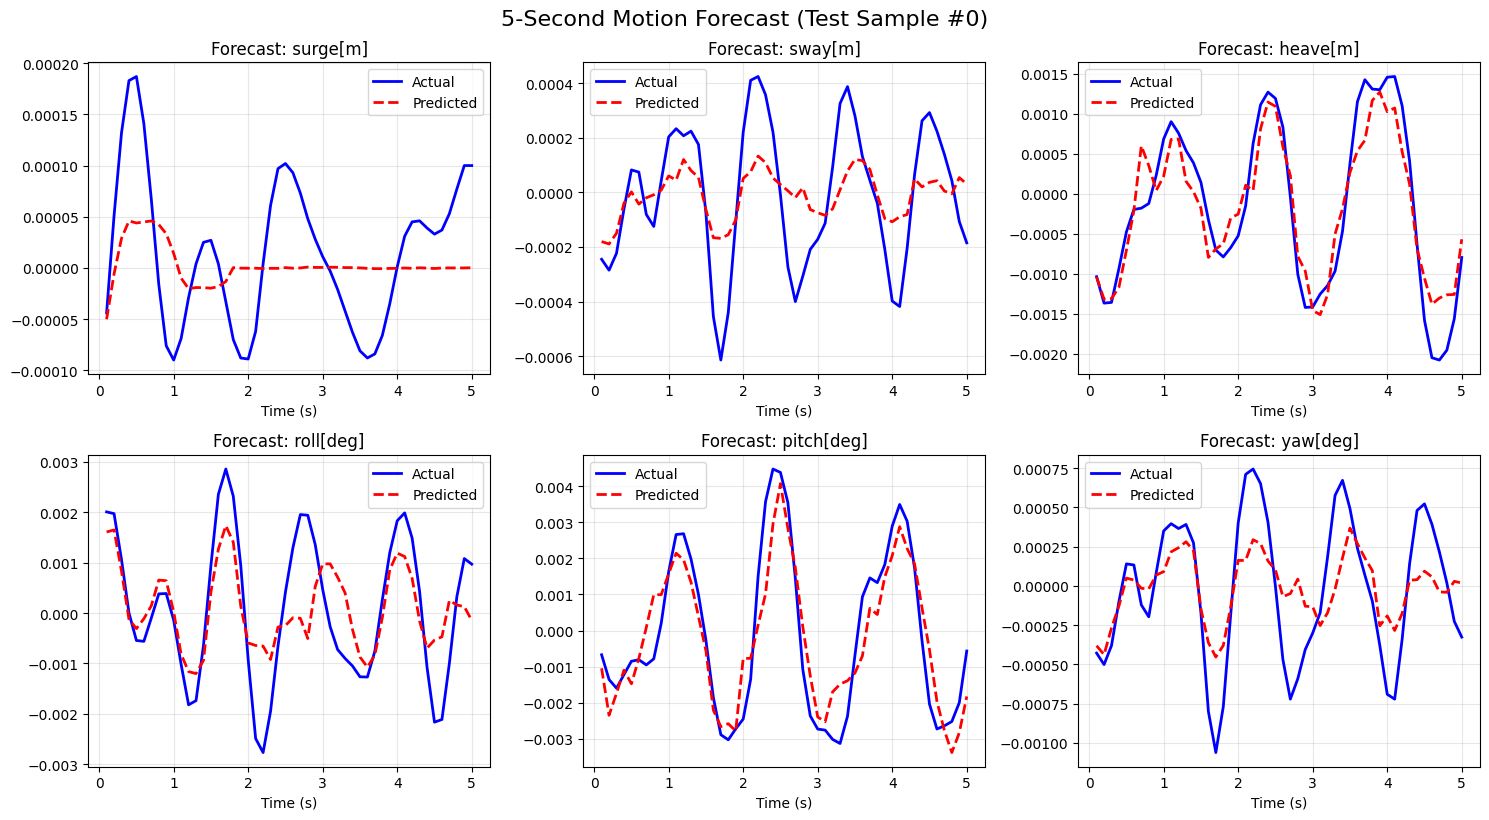

In [ ]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import io
from google.colab import files
from tqdm import tqdm

# ==========================================
# 1. UPLOAD DATA FILE
# ==========================================
print("Upload your BTP data file (Excel .xlsx or CSV .csv):")
uploaded = files.upload()

filename = next(iter(uploaded))
print(f"\nProcessing file: {filename}")

try:
    if filename.endswith('.csv'):
        df = pd.read_csv(io.BytesIO(uploaded[filename]))
    else:
        try:
            df = pd.read_excel(io.BytesIO(uploaded[filename]), sheet_name='Time-Series Data')
        except:
            df = pd.read_excel(io.BytesIO(uploaded[filename]))
    print("Data loaded successfully.")

except Exception as e:
    print(f"Error loading file: {e}")
    raise

# ==========================================
# 2. PREPROCESS DATA
# ==========================================
target_cols = ['surge[m]', 'sway[m]', 'heave[m]', 'roll[deg]', 'pitch[deg]', 'yaw[deg]']

# Clean column names just in case
df.columns = df.columns.str.strip()
data_6dof = df[target_cols].values

def create_windows(data, input_steps=100, output_steps=50):
    X, y = [], []
    total_len = len(data)
    for i in tqdm(range(total_len - input_steps - output_steps + 1), desc="Creating Windows"):
        X.append(data[i : i + input_steps].flatten())
        y.append(data[i + input_steps : i + input_steps + output_steps].flatten())
    return np.array(X), np.array(y)

input_steps = 100
output_steps = 50

print("\nProcessing windows...")
X, y = create_windows(data_6dof, input_steps, output_steps)
print(f"Dataset shape: X={X.shape}, y={y.shape}")

split_idx = int(0.8 * len(X))
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

# ==========================================
# 3. TRAIN XGBOOST MODEL (FAST VERSION)
# ==========================================
print("\nTraining XGBoost model...")

# Check for GPU
try:
    import torch
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    tree_method = 'hist'
except:
    device = 'cpu'
    tree_method = 'hist'

print(f"Training on: {device.upper()}")

model = xgb.XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    tree_method=tree_method,
    device=device,
    n_jobs=-1,
    random_state=42
)

model.fit(X_train, y_train)
print("Training complete!")

# ==========================================
# 4. EVALUATE (Overall & Per-Motion RMSE)
# ==========================================
y_pred = model.predict(X_test)

# --- Overall Metrics ---
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
print(f"\nTest Set Metrics:")
print(f"Overall RMSE: {np.sqrt(mse):.6f}")
print(f"Overall MAE:  {mae:.6f}")

# --- Per-Motion RMSE Calculation ---
# Reshape arrays back to (Samples, TimeSteps, 6_Variables)
# y_test was (N, 300) -> becomes (N, 50, 6)
y_test_reshaped = y_test.reshape(-1, output_steps, 6)
y_pred_reshaped = y_pred.reshape(-1, output_steps, 6)

print("\nPer-Motion RMSE:")
print("-" * 30)
# Loop through each of the 6 columns
for i, col_name in enumerate(target_cols):
    # Slice the 3D array to get all samples and all timesteps for just the i-th variable
    true_var = y_test_reshaped[:, :, i]
    pred_var = y_pred_reshaped[:, :, i]

    mse_var = mean_squared_error(true_var, pred_var)
    rmse_var = np.sqrt(mse_var)

    print(f"{col_name:<12}: {rmse_var:.6f}")
print("-" * 30)

# ==========================================
# 5. VISUALIZATION
# ==========================================
sample_idx = 0
true_sample = y_test[sample_idx].reshape(output_steps, 6)
pred_sample = y_pred[sample_idx].reshape(output_steps, 6)
time_axis = np.arange(1, output_steps + 1) / 10.0

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col_name in enumerate(target_cols):
    ax = axes[i]
    ax.plot(time_axis, true_sample[:, i], 'b-', label='Actual', linewidth=2)
    ax.plot(time_axis, pred_sample[:, i], 'r--', label='Predicted', linewidth=2)
    ax.set_title(f"Forecast: {col_name}")
    ax.set_xlabel("Time (s)")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.suptitle(f"5-Second Motion Forecast (Test Sample #{sample_idx})", y=1.02, fontsize=16)
plt.show()